In [1]:
import pandas as pd
df = pd.read_csv('Next Word Predictor Dataset.txt', sep='\t', header=None)
df.head()

,0
0,I hope this email finds you well
1,Thank you for your prompt response
2,I appreciate your valuable input on this matter
3,Please find attached the document you requested
4,I am writing to inform you about the upcoming ...


In [2]:
df = df.astype('string')

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [4]:
tokenizer = Tokenizer(oov_token="<OOV>")

In [5]:
tokenizer.fit_on_texts(df[0].astype(str))

In [6]:
len(tokenizer.word_index)

3151

In [7]:
input_sequences = []
for sentence in df[0]:
  tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]

  for i in range(1,len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])

In [8]:
len(input_sequences)

49976

In [9]:
max_len = max([len(x) for x in input_sequences])
max_len

21

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_input_sequences = pad_sequences(input_sequences, maxlen = max_len, padding='pre')

In [11]:
padded_input_sequences

array([[   0,    0,    0, ...,    0,    5, 1427],
       [   0,    0,    0, ...,    5, 1427,   60],
       [   0,    0,    0, ..., 1427,   60, 1674],
       ...,
       [   0,    0,    0, ..., 1209,  103, 1650],
       [   0,    0,    0, ...,  103, 1650,    9],
       [   0,    0,    0, ..., 1650,    9, 3151]])

In [12]:
X = padded_input_sequences[:,:-1]

In [13]:
y = padded_input_sequences[:,-1]

In [14]:
X.shape

(49976, 20)

In [15]:
y.shape

(49976,)

In [16]:
from tensorflow.keras.utils import to_categorical
y = to_categorical(y,num_classes=3152)

In [17]:
y.shape

(49976, 3152)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,Dropout

In [24]:
model = Sequential()
model.add(Embedding(3152, 200, input_length=20))
model.add(LSTM(200, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(200))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dense(3152, activation='softmax'))

In [25]:
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

In [28]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
1250/1250 [==============================] - 30s 24ms/step - loss: 2.2163 - accuracy: 0.4597 - val_loss: 7.5123 - val_accuracy: 0.2516
Epoch 2/100
1250/1250 [==============================] - 33s 26ms/step - loss: 2.1140 - accuracy: 0.4736 - val_loss: 7.7607 - val_accuracy: 0.2473
Epoch 3/100
1250/1250 [==============================] - 33s 26ms/step - loss: 2.0110 - accuracy: 0.4883 - val_loss: 8.0885 - val_accuracy: 0.2464
Epoch 4/100
1250/1250 [==============================] - 30s 24ms/step - loss: 1.9274 - accuracy: 0.4985 - val_loss: 8.1195 - val_accuracy: 0.2543
Epoch 5/100
1250/1250 [==============================] - 31s 25ms/step - loss: 1.8528 - accuracy: 0.5112 - val_loss: 8.5434 - val_accuracy: 0.2552
Epoch 6/100
1250/1250 [==============================] - 33s 27ms/step - loss: 1.7798 - accuracy: 0.5225 - val_loss: 8.6923 - val_accuracy: 0.2634
Epoch 7/100
1250/1250 [==============================] - 31s 25ms/step - loss: 1.7164 - accuracy: 0.5349 - val_loss: 8

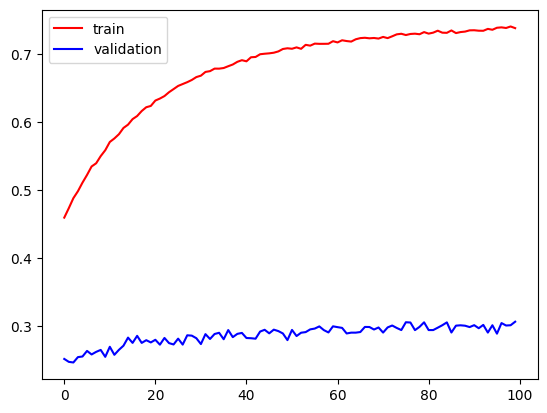

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

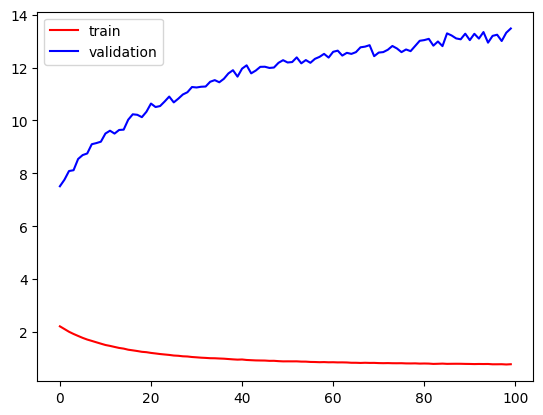

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [31]:
import numpy as np
import time
text = "I'm"

for i in range(10):
  # tokenize
  token_text = tokenizer.texts_to_sequences([text])[0]
  # padding
  padded_token_text = pad_sequences([token_text], maxlen=20, padding='pre')
  # predict
  pos = np.argmax(model.predict(padded_token_text))

  for word,index in tokenizer.word_index.items():
    if index == pos:
      text = text + " " + word
      print(text)
      time.sleep(2)

1/1 [==============================] - 0s 36ms/step
I'm considering
1/1 [==============================] - 0s 44ms/step
I'm considering adopting
1/1 [==============================] - 0s 38ms/step
I'm considering adopting a
1/1 [==============================] - 0s 39ms/step
I'm considering adopting a more
1/1 [==============================] - 0s 33ms/step
I'm considering adopting a more sustainable
1/1 [==============================] - 0s 34ms/step
I'm considering adopting a more sustainable shopping
1/1 [==============================] - 0s 37ms/step
I'm considering adopting a more sustainable shopping approach
1/1 [==============================] - 0s 41ms/step
I'm considering adopting a more sustainable shopping approach for
1/1 [==============================] - 0s 37ms/step
I'm considering adopting a more sustainable shopping approach for ethical
1/1 [==============================] - 0s 37ms/step
I'm considering adopting a more sustainable shopping approach for ethical choices

In [41]:
model.save("my_model.keras")

In [43]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [45]:
import tensorflow as tf
import keras

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.10.0
Keras Version: 2.10.0
